# Enhanced Text Analysis with Apache Beam

**Modified by: Malav**

This notebook extends the basic Apache Beam word count example with substantial modifications:

- **Different Dataset**: Uses Shakespeare's *Romeo and Juliet* instead of *King Lear*
- **Stop Word Filtering**: Removes common English stop words for meaningful analysis
- **Case Normalization**: Converts all words to lowercase for accurate counting
- **Bigram Analysis**: Extracts and counts word pairs (2-grams)
- **Word Length Distribution**: Analyzes the distribution of word lengths
- **Top-K Results**: Filters to show only the most frequent items
- **Visualization**: Generates bar charts for top words, bigrams, and word length distribution

Built using the [DirectRunner](https://beam.apache.org/documentation/runners/direct/).

## 1. Setup

Install dependencies and download *Romeo and Juliet* from Project Gutenberg.

In [1]:
# Install required packages
%pip install --quiet apache-beam matplotlib pandas==2.0.3 scikit-learn nltk

import subprocess
import os

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Download Romeo and Juliet from Project Gutenberg
import urllib.request
url = 'https://www.gutenberg.org/cache/epub/1513/pg1513.txt'
filepath = 'data/romeo_and_juliet.txt'

if not os.path.exists(filepath):
    urllib.request.urlretrieve(url, filepath)
    print(f'Downloaded Romeo and Juliet to {filepath}')
else:
    print(f'File already exists: {filepath}')

# Preview the first 20 lines
with open(filepath, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(line, end='')

Note: you may need to restart the kernel to use updated packages.
File already exists: data/romeo_and_juliet.txt
﻿The Project Gutenberg eBook of Romeo and Juliet
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Romeo and Juliet

Author: William Shakespeare

Release date: November 1, 1998 [eBook #1513]
                Most recently updated: September 18, 2025

Language: English

Credits: the PG Shakespeare Team, a team of about twenty Project Gutenberg volunteers


## 2. Define Stop Words and Helper Functions

We define a set of common English stop words to filter out, plus helper functions for our custom transforms.

In [2]:
import apache_beam as beam
import re
from collections import defaultdict

# Common English stop words to filter out
STOP_WORDS = {
    'the', 'and', 'is', 'in', 'to', 'of', 'a', 'i', 'that', 'it',
    'for', 'you', 'was', 'with', 'on', 'are', 'as', 'at', 'be', 'this',
    'have', 'from', 'or', 'an', 'but', 'not', 'by', 'what', 'all', 'can',
    'had', 'her', 'his', 'him', 'my', 'me', 'so', 'no', 'do', 'if',
    'they', 'which', 'will', 'would', 'there', 'their', 'he', 'she',
    'we', 'them', 'been', 'has', 'when', 'who', 'our', 'shall', 'than',
    'its', 'did', 'how', 'were', 'then', 'am', 'more', 'your', 'up',
    'out', 'some', 'could', 'into', 'may', 'now', 'very', 'thy', 'thee',
    'thou', 'hath', 'doth', 'o', 'upon', 'art', 'ere', 'yet', 'nor'
}

def extract_words(line):
    """Extract words from a line, lowercase and filter stop words + short words."""
    words = re.findall(r"[a-zA-Z']+", line)
    return [w.lower() for w in words if w.lower() not in STOP_WORDS and len(w) > 1]

def extract_bigrams(line):
    """Extract bigrams (consecutive word pairs) from a line."""
    words = extract_words(line)
    return [f'{words[i]} {words[i+1]}' for i in range(len(words) - 1)]

def get_word_length(word):
    """Return the length category of a word."""
    return (str(len(word)), 1)

print('Helper functions defined successfully.')
print(f'Stop words count: {len(STOP_WORDS)}')

Helper functions defined successfully.
Stop words count: 84


## 3. Pipeline 1 — Enhanced Word Count (with Stop Word Filtering)

This pipeline reads *Romeo and Juliet*, normalizes case, removes stop words, counts word frequencies, and writes the results sorted by count.

In [3]:
input_file = 'data/romeo_and_juliet.txt'
word_count_output = 'outputs/word_counts'

with beam.Pipeline() as pipeline:
    word_counts = (
        pipeline
        # Read lines from Romeo and Juliet
        | 'Read lines' >> beam.io.ReadFromText(input_file)

        # Extract words: lowercase, remove stop words, filter short words
        | 'Extract clean words' >> beam.FlatMap(extract_words)

        # Pair each word with count of 1
        | 'Pair with 1' >> beam.Map(lambda word: (word, 1))

        # Sum counts per word
        | 'Sum counts' >> beam.CombinePerKey(sum)
    )

    # Write results formatted as "word: count", sorted by frequency
    (
        word_counts
        | 'Format word counts' >> beam.Map(lambda wc: f'{wc[0]}: {wc[1]}')
        | 'Write word counts' >> beam.io.WriteToText(word_count_output)
    )

print('--- Top 30 Words (by frequency) ---')
# Read and sort results
import glob
results = []
for f in glob.glob(f'{word_count_output}-*'):
    with open(f) as fh:
        for line in fh:
            parts = line.strip().rsplit(': ', 1)
            if len(parts) == 2:
                results.append((parts[0], int(parts[1])))

results.sort(key=lambda x: x[1], reverse=True)
for word, count in results[:30]:
    print(f'  {word:20s} {count}')

--- Top 30 Words (by frequency) ---
  romeo                320
  juliet               194
  capulet              163
  love                 151
  nurse                149
  lady                 117
  friar                105
  gutenberg            98
  come                 96
  here                 91
  ll                   91
  project              89
  mercutio             88
  good                 85
  lawrence             82
  enter                81
  tybalt               80
  benvolio             79
  go                   76
  death                74
  night                73
  man                  71
  where                63
  one                  63
  well                 62
  paris                61
  sir                  57
  too                  56
  say                  55
  any                  53


## 4. Pipeline 2 — Bigram Analysis

This pipeline extracts bigrams (pairs of consecutive words) and counts their frequencies. Bigrams reveal common phrases and collocations in the text.

In [4]:
bigram_output = 'outputs/bigram_counts'

with beam.Pipeline() as pipeline:
    bigram_counts = (
        pipeline
        | 'Read lines' >> beam.io.ReadFromText(input_file)

        # Extract bigrams from each line
        | 'Extract bigrams' >> beam.FlatMap(extract_bigrams)

        # Pair each bigram with 1
        | 'Pair bigram with 1' >> beam.Map(lambda bg: (bg, 1))

        # Sum counts per bigram
        | 'Sum bigram counts' >> beam.CombinePerKey(sum)
    )

    (
        bigram_counts
        | 'Format bigrams' >> beam.Map(lambda bc: f'{bc[0]}: {bc[1]}')
        | 'Write bigrams' >> beam.io.WriteToText(bigram_output)
    )

print('--- Top 25 Bigrams ---')
bigram_results = []
for f in glob.glob(f'{bigram_output}-*'):
    with open(f) as fh:
        for line in fh:
            parts = line.strip().rsplit(': ', 1)
            if len(parts) == 2:
                bigram_results.append((parts[0], int(parts[1])))

bigram_results.sort(key=lambda x: x[1], reverse=True)
for bigram, count in bigram_results[:25]:
    print(f'  {bigram:30s} {count}')

--- Top 25 Bigrams ---
  friar lawrence                 78
  project gutenberg              74
  lady capulet                   60
  electronic works               16
  lawrence cell                  15
  good night                     15
  gutenberg electronic           13
  archive foundation             13
  united states                  12
  capulet house                  12
  here comes                     11
  enter romeo                    11
  electronic work                11
  gutenberg literary             11
  scene ii                       10
  scene iii                      10
  ne er                          10
  first musician                 10
  literary archive               10
  gutenberg license              9
  www gutenberg                  9
  gutenberg org                  9
  friar john                     9
  enter capulet                  9
  enter juliet                   9


## 5. Pipeline 3 — Word Length Distribution

This pipeline computes how many words of each length appear in the text, giving insight into vocabulary complexity.

In [5]:
length_output = 'outputs/word_length_dist'

with beam.Pipeline() as pipeline:
    length_dist = (
        pipeline
        | 'Read lines' >> beam.io.ReadFromText(input_file)

        # Extract clean words
        | 'Extract words' >> beam.FlatMap(extract_words)

        # Map each word to its length
        | 'Map to length' >> beam.Map(get_word_length)

        # Sum counts per length
        | 'Sum by length' >> beam.CombinePerKey(sum)
    )

    (
        length_dist
        | 'Format lengths' >> beam.Map(lambda lc: f'{lc[0]}: {lc[1]}')
        | 'Write lengths' >> beam.io.WriteToText(length_output)
    )

print('--- Word Length Distribution ---')
length_results = []
for f in glob.glob(f'{length_output}-*'):
    with open(f) as fh:
        for line in fh:
            parts = line.strip().rsplit(': ', 1)
            if len(parts) == 2:
                length_results.append((int(parts[0]), int(parts[1])))

length_results.sort(key=lambda x: x[0])
for length, count in length_results:
    print(f'  Length {length:2d}: {count:5d} words')

--- Word Length Distribution ---
  Length  2:   412 words
  Length  3:  1523 words
  Length  4:  4065 words
  Length  5:  3761 words
  Length  6:  2326 words
  Length  7:  1628 words
  Length  8:  1074 words
  Length  9:   641 words
  Length 10:   344 words
  Length 11:   112 words
  Length 12:    49 words
  Length 13:    14 words
  Length 14:    10 words
  Length 15:     2 words
  Length 16:     1 words


## 6. Visualization

Generate bar charts for the top words, top bigrams, and word length distribution.

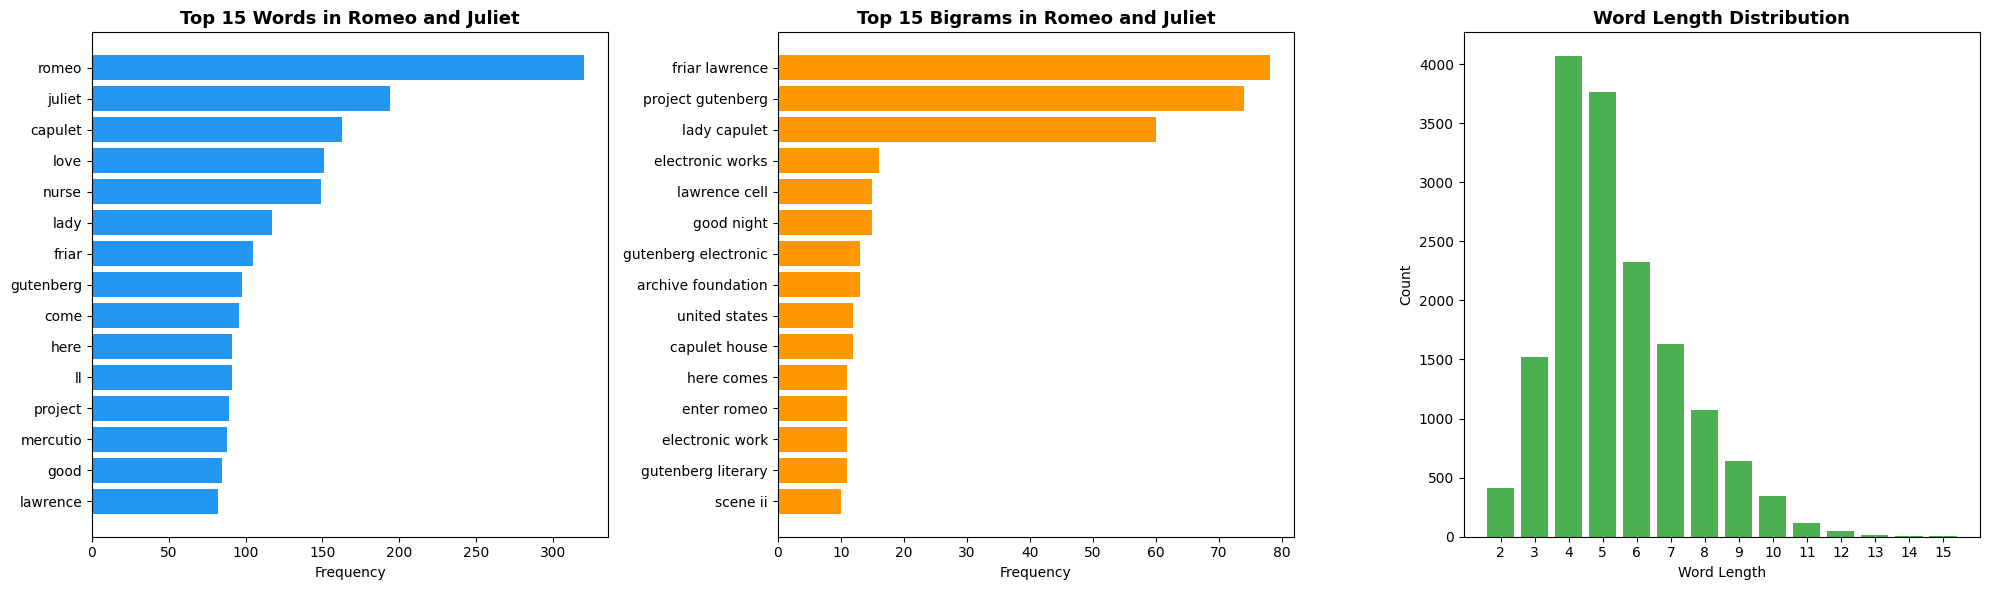


Plots saved to outputs/analysis_plots.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Top 15 Words ---
top_words = results[:15]
words = [w for w, c in top_words]
counts = [c for w, c in top_words]
axes[0].barh(words[::-1], counts[::-1], color='#2196F3')
axes[0].set_title('Top 15 Words in Romeo and Juliet', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# --- Plot 2: Top 15 Bigrams ---
top_bigrams = bigram_results[:15]
bigrams = [b for b, c in top_bigrams]
bg_counts = [c for b, c in top_bigrams]
axes[1].barh(bigrams[::-1], bg_counts[::-1], color='#FF9800')
axes[1].set_title('Top 15 Bigrams in Romeo and Juliet', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

# --- Plot 3: Word Length Distribution ---
lengths = [l for l, c in length_results if l <= 15]
len_counts = [c for l, c in length_results if l <= 15]
axes[2].bar(lengths, len_counts, color='#4CAF50')
axes[2].set_title('Word Length Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Word Length')
axes[2].set_ylabel('Count')
axes[2].set_xticks(lengths)

plt.tight_layout()
plt.savefig('outputs/analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nPlots saved to outputs/analysis_plots.png')

## 7. Summary Statistics

A quick statistical overview of the text analysis results.

In [7]:
total_unique_words = len(results)
total_word_occurrences = sum(c for _, c in results)
total_unique_bigrams = len(bigram_results)
avg_word_length = sum(l * c for l, c in length_results) / sum(c for _, c in length_results)

print('=' * 50)
print('     TEXT ANALYSIS SUMMARY: Romeo and Juliet')
print('=' * 50)
print(f'  Unique words (after filtering):  {total_unique_words:,}')
print(f'  Total word occurrences:          {total_word_occurrences:,}')
print(f'  Unique bigrams:                  {total_unique_bigrams:,}')
print(f'  Average word length:             {avg_word_length:.2f} characters')
print(f'  Most common word:                "{results[0][0]}" ({results[0][1]} times)')
print(f'  Most common bigram:              "{bigram_results[0][0]}" ({bigram_results[0][1]} times)')
print('=' * 50)

     TEXT ANALYSIS SUMMARY: Romeo and Juliet
  Unique words (after filtering):  3,899
  Total word occurrences:          15,962
  Unique bigrams:                  10,106
  Average word length:             5.38 characters
  Most common word:                "romeo" (320 times)
  Most common bigram:              "friar lawrence" (78 times)
